# MATH 189 — Group 11: Hypothesis Testing & Linear Regression

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.preprocessing import StandardScaler

os.makedirs("figures", exist_ok=True)
df = pd.read_csv("ca_aqi_acs_master_county_avg.csv")

---
## Part 1: Hypothesis Testing

We tested whether lower-income California counties experience statistically worse air quality than higher-income counties. Counties were split using the `lower_income_group` flag in the dataset, placing the bottom two income quartiles in the lower-income group (25 counties) and the top two in the higher-income group (28 counties).

We tested four air quality outcomes: Median AQI, percentage of bad AQI days, percentage of days where PM2.5 was the main pollutant, and percentage of days where ozone was the main pollutant.

For each outcome:

**Null hypothesis (H₀):** The mean air quality outcome is the same in lower-income and higher-income counties.

**Alternative hypothesis (Hₐ):** Lower-income counties have a worse (higher) air quality outcome than higher-income counties.

**Test statistic:** Welch t-statistic (one-sided), confirmed with a Mann-Whitney U test. Significance level α = 0.05.

In [2]:
low  = df[df["lower_income_group"] == True]
high = df[df["lower_income_group"] == False]

outcomes = {
    "avg_median_aqi_2020_2024":                    "Median AQI",
    "avg_bad_aqi_day_pct_2020_2024":               "% Bad AQI Days",
    "avg_pct_days_pm25_main_pollutant_2020_2024":  "% Days PM2.5 Main",
    "avg_pct_days_ozone_main_pollutant_2020_2024": "% Days Ozone Main",
}

rows = []
for col, label in outcomes.items():
    x_low  = low[col].dropna()
    x_high = high[col].dropna()

    t_stat, t_p_two = stats.ttest_ind(x_low, x_high, equal_var=False)
    t_p_one = t_p_two / 2 if t_stat > 0 else 1 - t_p_two / 2

    _, mwu_p = stats.mannwhitneyu(x_low, x_high, alternative="greater")

    pooled_std = np.sqrt((x_low.std(ddof=1)**2 + x_high.std(ddof=1)**2) / 2)
    d = (x_low.mean() - x_high.mean()) / pooled_std

    rows.append({
        "Outcome":        label,
        "Mean (Low-Inc)": round(x_low.mean(), 3),
        "Mean (Hi-Inc)":  round(x_high.mean(), 3),
        "t-stat":         round(t_stat, 4),
        "p (1-tail)": round(t_p_one, 4),
        "MWU p":          round(mwu_p, 4),
        "Cohen's d":      round(d, 3),
        "Sig (a=0.05)":   "Yes" if t_p_one < 0.05 else "No",
    })

results = pd.DataFrame(rows)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(results.to_string(index=False))

          Outcome  Mean (Low-Inc)  Mean (Hi-Inc)  t-stat  p (1-tail)  MWU p  Cohen's d Sig (a=0.05)
       Median AQI          50.544         48.479  0.5565      0.2901 0.1702      0.153           No
   % Bad AQI Days           7.838          6.464  0.5311      0.2989 0.0367      0.145           No
% Days PM2.5 Main          45.936         47.268 -0.2112      0.5831 0.8939     -0.059           No
% Days Ozone Main          50.288         49.234  0.1630      0.4356 0.2520      0.045           No


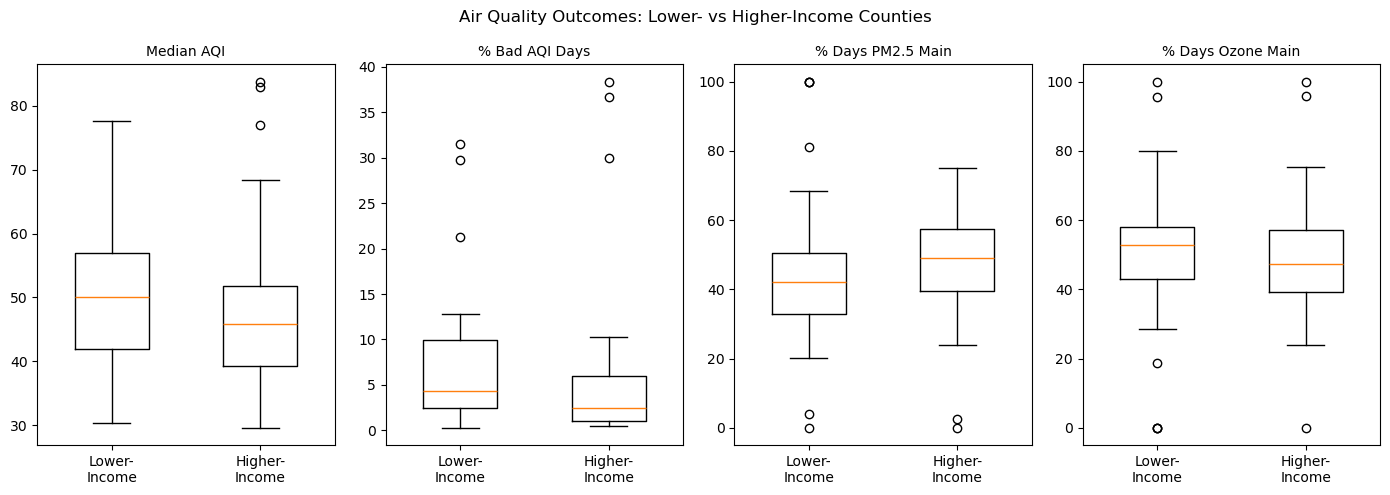

In [3]:
# Figure 1: Boxplots
fig, axes = plt.subplots(1, len(outcomes), figsize=(14, 5))

for ax, (col, label) in zip(axes, outcomes.items()):
    data = [low[col].dropna().values, high[col].dropna().values]
    ax.boxplot(data, tick_labels=["Lower-\nIncome", "Higher-\nIncome"], widths=0.5)
    ax.set_title(label, fontsize=10)

plt.suptitle("Air Quality Outcomes: Lower- vs Higher-Income Counties", fontsize=12)
plt.tight_layout()
plt.savefig("figures/hypothesis_boxplots.png")
plt.show()

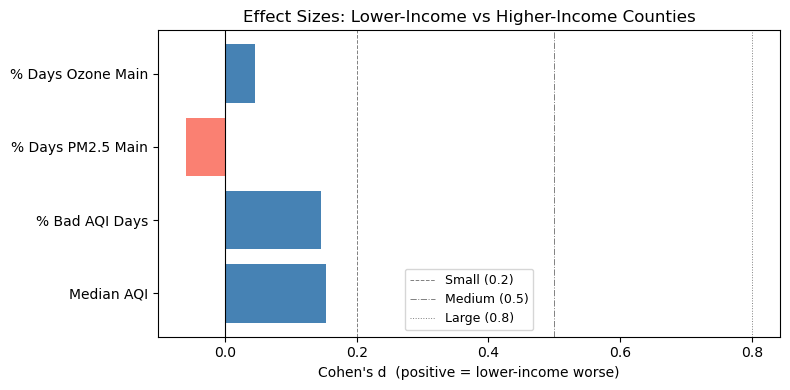

In [4]:
# Figure 2: Cohen's d
fig, ax = plt.subplots(figsize=(8, 4))
labels   = [r["Outcome"] for r in rows]
d_values = [r["Cohen's d"] for r in rows]
colors   = ["steelblue" if d > 0 else "salmon" for d in d_values]
ax.barh(labels, d_values, color=colors)
ax.axvline(0,   color="black", linewidth=0.8)
ax.axvline(0.2, color="gray",  linestyle="--", linewidth=0.7, label="Small (0.2)")
ax.axvline(0.5, color="gray",  linestyle="-.", linewidth=0.7, label="Medium (0.5)")
ax.axvline(0.8, color="gray",  linestyle=":",  linewidth=0.7, label="Large (0.8)")
ax.set_xlabel("Cohen's d  (positive = lower-income worse)")
ax.set_title("Effect Sizes: Lower-Income vs Higher-Income Counties")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/hypothesis_effect_sizes.png")
plt.show()

### Results

None of the four outcomes produced a statistically significant difference at α = 0.05. For Median AQI, the lower-income group averaged 50.5 versus 48.5 for higher-income counties, but the Welch t-test returned t = 0.557 and p = 0.290, with a Cohen's d of 0.153. For percentage of bad AQI days, the means were 7.8 versus 6.5, with t = 0.531, p = 0.299, and d = 0.145. For percentage of days where PM2.5 was the main pollutant, lower-income counties actually averaged slightly lower (45.9 vs 47.3), producing t = -0.211 and a negative d of -0.059. For ozone, the difference was similarly negligible (t = 0.163, p = 0.436).

The Mann-Whitney U test on percentage of bad AQI days returned p = 0.037, which crosses the threshold in isolation, but does not hold up alongside the other three non-significant results.

### Interpretation

At the county level, income group alone does not clearly separate worse air quality from better. Cohen's d values are all below 0.2, meaning even the directional differences are small in practical terms. This likely reflects the coarseness of county-level aggregation — some of California's highest-income counties sit geographically close to the heavily polluted Central Valley, which compresses any income-based signal when averaged at the county scale.

---
## Part 2: Linear Regression

We fit multiple linear regression models to estimate how well socioeconomic variables predict air quality outcomes across 53 California counties. The five predictors were median household income, poverty rate, unemployment rate, percentage with a bachelor's degree or higher, and percentage with no health insurance. All predictors were standardized before fitting so their coefficients are directly comparable in magnitude.

Three separate OLS models were fit, one each for Median AQI, percentage of bad AQI days, and percentage of days where PM2.5 was the main pollutant.

**Null hypothesis (H₀):** The socioeconomic predictors have no linear relationship with the air quality outcome (all slope coefficients equal zero).

**Alternative hypothesis (Hₐ):** At least one socioeconomic predictor has a nonzero linear relationship with the air quality outcome.

**Test statistic:** F-statistic from the omnibus F-test. Individual predictors are evaluated with t-statistics on each coefficient. Significance level α = 0.05.

In [5]:
predictors = [
    "median_household_income",
    "poverty_rate_all_people",
    "unemployment_rate",
    "pct_bachelors_or_higher",
    "pct_no_health_insurance",
]

reg_outcomes = {
    "avg_median_aqi_2020_2024":                   "Median AQI",
    "avg_bad_aqi_day_pct_2020_2024":              "% Bad AQI Days",
    "avg_pct_days_pm25_main_pollutant_2020_2024": "% Days PM2.5 Main",
}

reg_df   = df[predictors + list(reg_outcomes.keys())].dropna().copy()
X_scaled = StandardScaler().fit_transform(reg_df[predictors])
X_df     = pd.DataFrame(X_scaled, columns=predictors, index=reg_df.index)
X        = sm.add_constant(X_df)

models = {}
for col, label in reg_outcomes.items():
    model = sm.OLS(reg_df[col], X).fit()
    models[col] = model
    print(f"\n{'='*55}")
    print(f"Outcome: {label}")
    print(f"  R²      = {model.rsquared:.4f}")
    print(f"  Adj. R² = {model.rsquared_adj:.4f}")
    print(f"  F-stat  = {model.fvalue:.4f}  (p = {model.f_pvalue:.4f})")
    print(model.summary())


Outcome: Median AQI
  R²      = 0.1561
  Adj. R² = 0.0663
  F-stat  = 1.7387  (p = 0.1443)
                               OLS Regression Results                               
Dep. Variable:     avg_median_aqi_2020_2024   R-squared:                       0.156
Model:                                  OLS   Adj. R-squared:                  0.066
Method:                       Least Squares   F-statistic:                     1.739
Date:                      Sun, 07 Jun 2026   Prob (F-statistic):              0.144
Time:                              18:51:51   Log-Likelihood:                -208.08
No. Observations:                        53   AIC:                             428.2
Df Residuals:                            47   BIC:                             440.0
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
                              coef    std err          t  

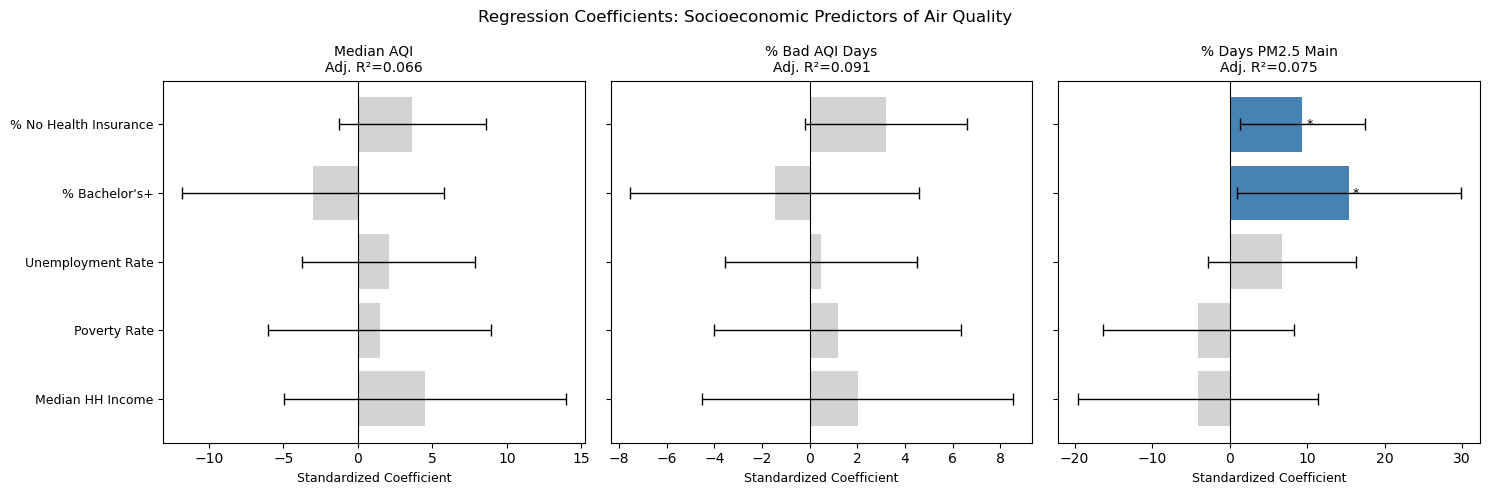

In [6]:
pred_labels = {
    "median_household_income": "Median HH Income",
    "poverty_rate_all_people": "Poverty Rate",
    "unemployment_rate":       "Unemployment Rate",
    "pct_bachelors_or_higher": "% Bachelor's+",
    "pct_no_health_insurance": "% No Health Insurance",
}

# Figure 3: Coefficient plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, (col, label) in zip(axes, reg_outcomes.items()):
    model = models[col]
    coef  = model.params.drop("const")
    conf  = model.conf_int().drop("const")
    pvals = model.pvalues.drop("const")

    y_pos  = np.arange(len(coef))
    colors = ["steelblue" if p < 0.05 else "lightgray" for p in pvals]

    ax.barh(y_pos, coef.values, color=colors,
            xerr=[coef.values - conf[0].values, conf[1].values - coef.values],
            capsize=4, error_kw={"linewidth": 1})
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([pred_labels[v] for v in predictors], fontsize=9)
    ax.set_title(f"{label}\nAdj. R²={model.rsquared_adj:.3f}", fontsize=10)
    ax.set_xlabel("Standardized Coefficient", fontsize=9)

    for i, (c, p) in enumerate(zip(coef.values, pvals)):
        star = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        if star:
            ax.text(c + (0.5 if c >= 0 else -0.5), i, star,
                    va="center", ha="left" if c >= 0 else "right", fontsize=9)

plt.suptitle("Regression Coefficients: Socioeconomic Predictors of Air Quality", fontsize=12)
plt.tight_layout()
plt.savefig("figures/regression_coefficients.png")
plt.show()

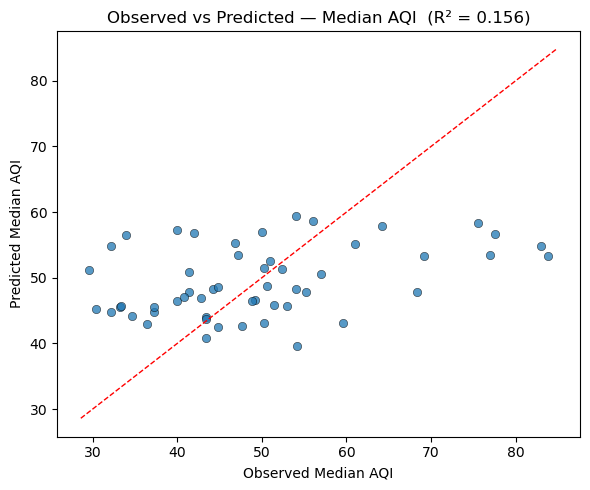

In [7]:
# Figure 4: Observed vs Predicted (Median AQI)
primary = models["avg_median_aqi_2020_2024"]
fitted  = primary.fittedvalues
y_true  = reg_df["avg_median_aqi_2020_2024"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_true, fitted, alpha=0.75, edgecolors="k", linewidths=0.4)
lim = [min(y_true.min(), fitted.min()) - 1, max(y_true.max(), fitted.max()) + 1]
ax.plot(lim, lim, "r--", linewidth=1)
ax.set_xlabel("Observed Median AQI")
ax.set_ylabel("Predicted Median AQI")
ax.set_title(f"Observed vs Predicted — Median AQI  (R² = {primary.rsquared:.3f})")
plt.tight_layout()
plt.savefig("figures/regression_observed_vs_predicted.png")
plt.show()

### Results

For Median AQI, the model produced an R² of 0.156 and an adjusted R² of 0.069. The F-statistic was 1.74 with p = 0.144, meaning the predictors as a set did not significantly explain variation in median AQI. No individual predictor reached significance, though percentage with no health insurance had the largest positive coefficient (3.64).

For percentage of bad AQI days, the model explained slightly more variance with R² = 0.178 and adjusted R² = 0.094. The F-test returned F = 2.04 with p = 0.090, again non-significant. Percentage with no health insurance had the largest coefficient (3.21, p = 0.065), narrowly missing significance.

For percentage of days where PM2.5 was the main pollutant, R² was 0.164 with adjusted R² of 0.076 and F = 1.84 with p = 0.123. Two predictors reached significance at α = 0.05: percentage with a bachelor's degree or higher (β = 15.40, t = 2.15, p = 0.037) and percentage with no health insurance (β = 9.38, t = 2.33, p = 0.024).

### Interpretation

The omnibus F-tests are all non-significant, meaning the five socioeconomic variables as a group do not reliably predict county-level AQI. Adjusted R² values below 0.10 across all three models confirm they explain little of the variance.

The two significant coefficients in the PM2.5 model warrant some caution. The positive sign on education likely reflects a geographic artifact: Bay Area and coastal counties, which tend to have higher education levels, also happen to be places where PM2.5 dominates over ozone as the primary pollutant. The positive coefficient on percentage with no health insurance is more consistent with an environmental justice interpretation, but the overall model fit is too weak to draw causal conclusions.

As with the hypothesis tests, county-level aggregation is likely masking the income–pollution relationship that would be more visible at finer geographic scales such as ZIP code or census tract.